# **Incidencia y tasa de mortalidad estándar**

In [12]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# Leer shapefile
gdf = gpd.read_file("Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

df = pd.read_csv(r"https://media.githubusercontent.com/media/Darally06/DATOS_DENGUE/refs/heads/main/Data_Atlantico.csv", encoding="latin_1")
poblacion = pd.read_csv("Datos adjuntos/Poblacion_departamental.csv", encoding="latin_1")

## *Incidencia de casos por cada 1,000 habitantes*

In [13]:
# [Tabla] Casos por municipio
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")

# Ajustar nombres de columna para unir
poblacion = poblacion.rename(columns={'MUNICIPIO':'municipio', 'TOTAL':'total_pob'})

# Convertir columnas de año en una columna 'año'
poblacion_long = poblacion.melt(
    id_vars=['municipio', 'total_pob'],    # mantener municipio y total
    value_vars=['2017.0','2018.0','2019.0','2020.0','2021.0','2022.0','2023.0'],
    var_name='año',
    value_name='poblacion'
)

# Asegurarse de que 'año' sea numérico
poblacion_long['año'] = poblacion_long['año'].astype(float).astype(int)

# Unir casos con población del mismo año
tabla_mun = tabla_mun.merge(poblacion_long, on=['municipio','año'], how='left')

# incidencia por año y municipio
tabla_mun['incidencia'] = tabla_mun['casos'] / tabla_mun['poblacion']

# Si quieres por cada 1000 habitantes
tabla_mun['incidencia'] = (tabla_mun['casos'] / tabla_mun['poblacion']) * 1000

tabla_mun = tabla_mun.sort_values(by='incidencia', ascending=False)

In [14]:
# incidencia global por municipio (todos los años)
incidencia = tabla_mun.groupby("municipio").agg(
    casos_totales=('casos', 'sum'),
    poblacion_total=('total_pob', 'first')   # la misma población total por municipio
).reset_index()

incidencia['incidencia'] = (incidencia['casos_totales'] / incidencia['poblacion_total']) * 10000

# Ordenar de mayor a menor
incidencia = incidencia.sort_values(by='incidencia', ascending=False)

incidencia.head(10)


,municipio,casos_totales,poblacion_total,incidencia
10,POLONUEVO,399,155707.0,25.625052
0,BARANOA,1028,539600.0,19.051149
12,PUERTO COLOMBIA,780,443890.0,17.571921
3,GALAPA,876,519297.0,16.868959
6,MALAMBO,1697,1105302.0,15.353270
4,JUAN DE ACOSTA,252,178618.0,14.108321
15,SABANALARGA,1093,785276.0,13.918673
18,SOLEDAD,6997,5229151.0,13.380757
5,LURUACO,284,240991.0,11.784672
19,SUAN,119,103469.0,11.501029


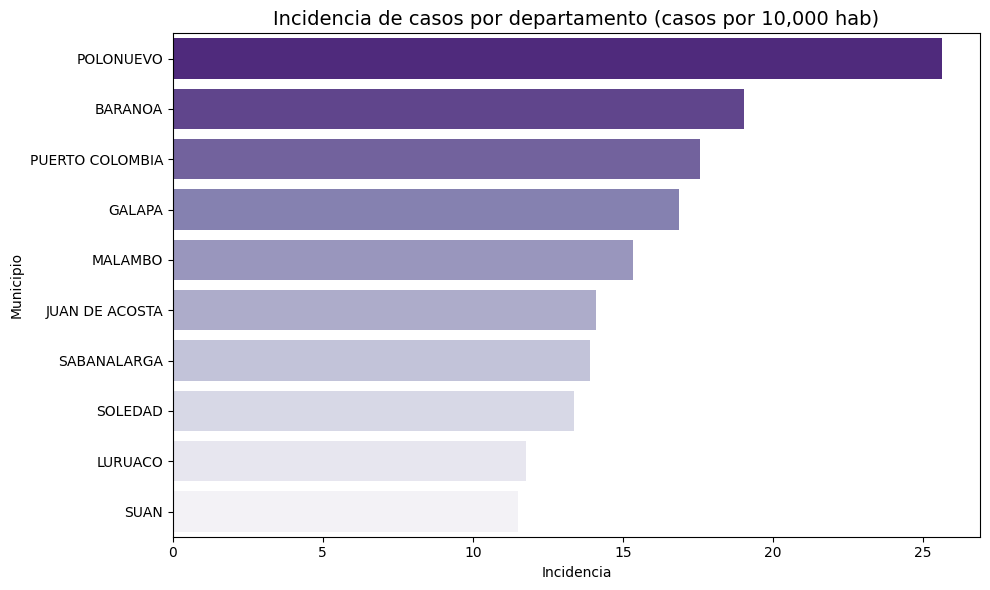

In [15]:
top10 = incidencia.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='incidencia', y='municipio', hue='municipio', palette='Purples_r')

plt.title("Incidencia de casos por departamento (casos por 10,000 hab)", fontsize=14)
plt.xlabel("Incidencia")
plt.ylabel("Municipio")
plt.tight_layout()
plt.show()


In [16]:
incidencia['incidencia'].describe()

count    15.000000
mean     12.532393
std       6.143234
min       3.518536
25%       8.488547
50%      13.380757
75%      16.111115
max      25.625052
Name: incidencia, dtype: float64

<Axes: xlabel='incidencia'>

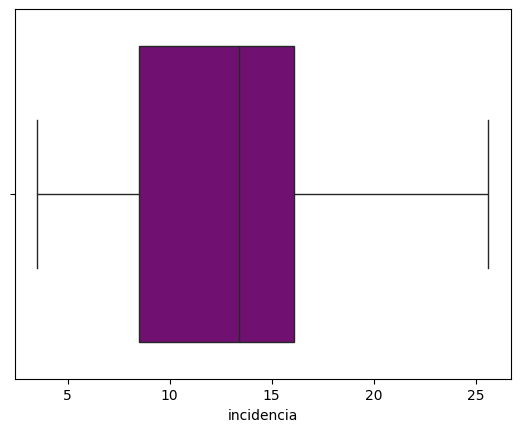

In [17]:
sns.boxplot(data=incidencia, x='incidencia', color='Purple')

La densidad poblacional de casos de dengue por municipio presenta una gran variabilidad. El valor promedio es de aproximadamente 14.3 casos por cada 10,000 habitantes, con una desviación estándar de 8.4 casos. Un 25% de los municipios reporta entre 7 a 14.3 casos, mostrando entonces la mitad de los territorios no reportan más de 15 casos por cada 10,000 habitantes. El municipio de Usiacurí es el de mayor densidad de casos (37), este es un dato atípico al conjunto, representando una tasa muy alta. La distribución de la densidad es sesgada hacia la derecha, con municipios de Polovuevo, Baranoa, Galapa y Puerto Colombia reportando más de 20 casos por cada 10,000 habitantes. 

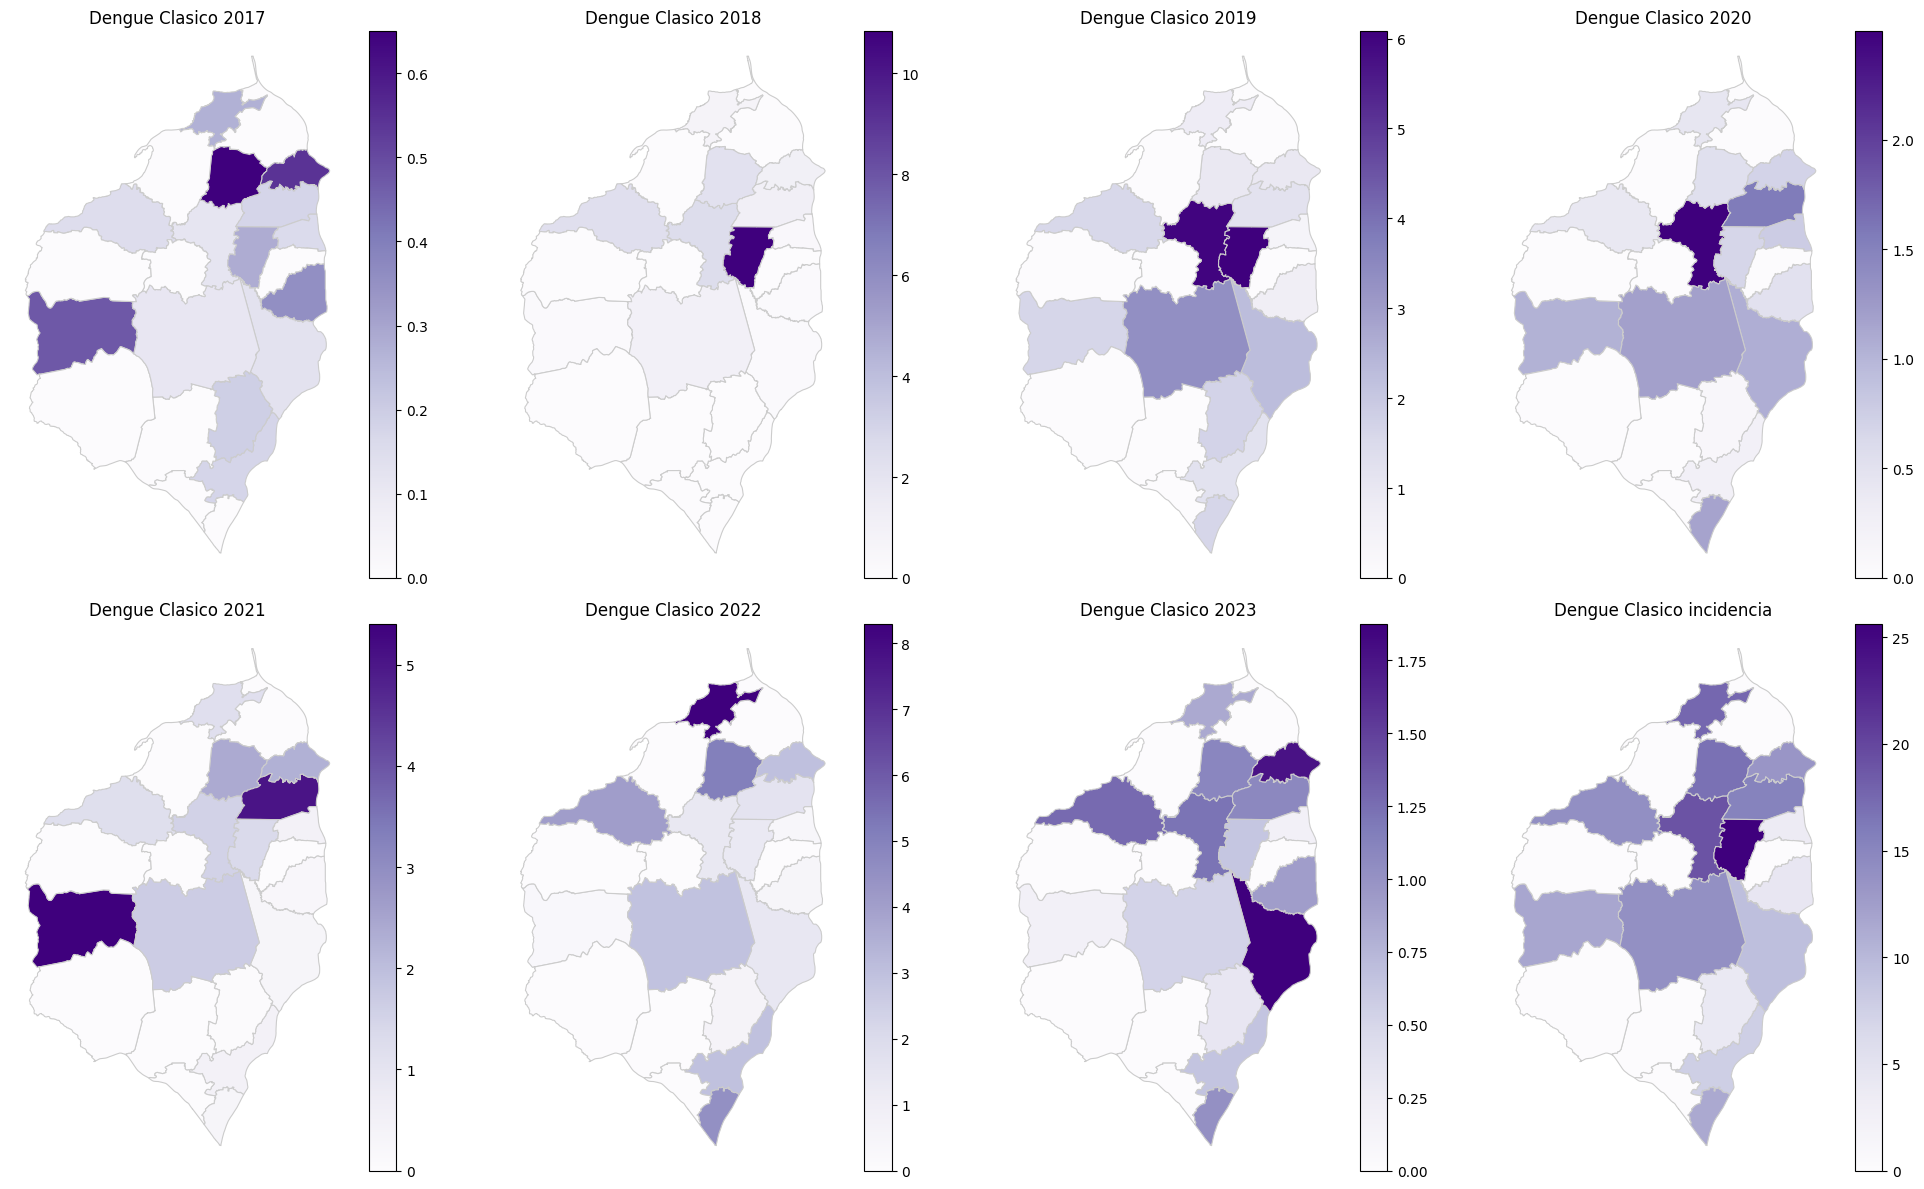

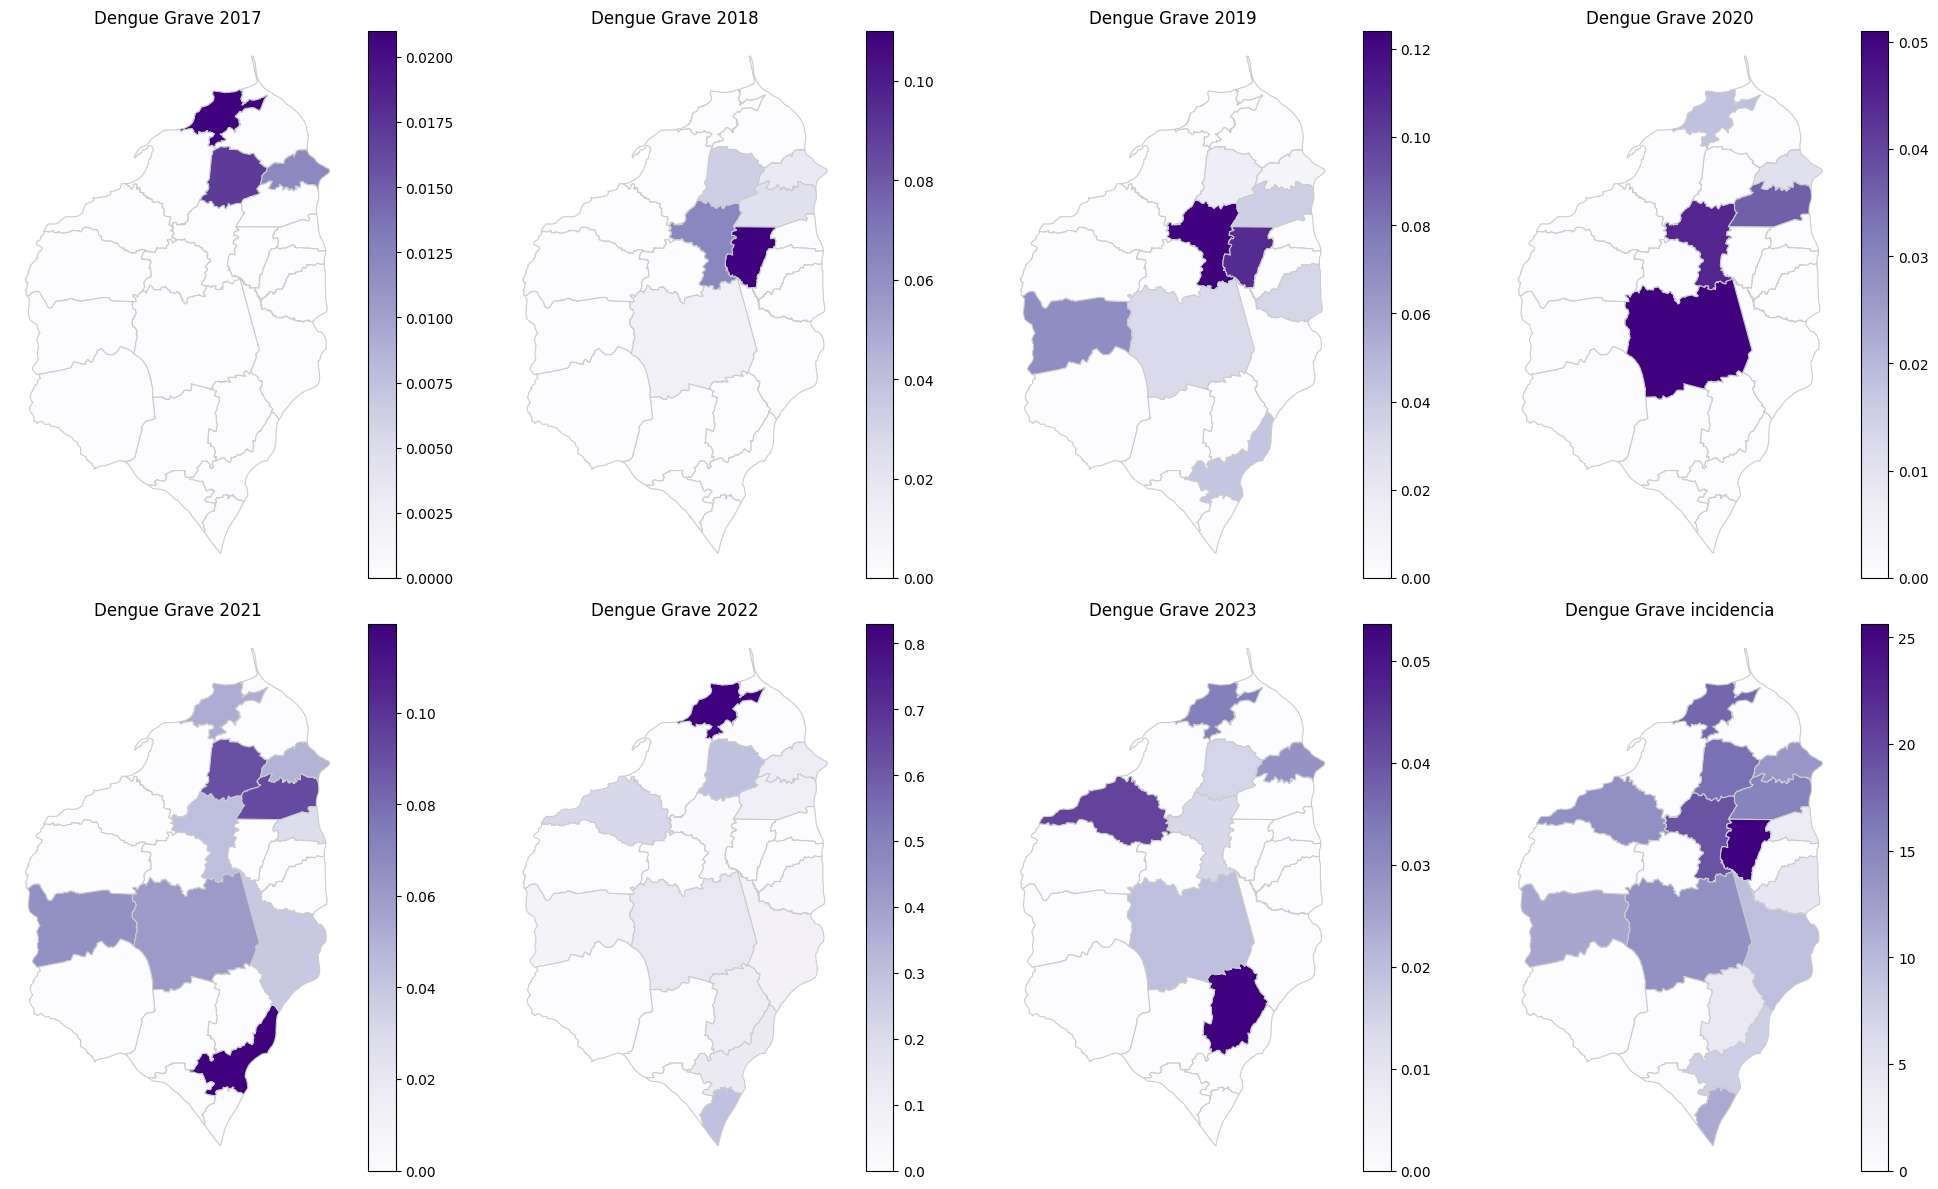

In [20]:
# [Gráfico] Mapa casos por municipio según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            tabla_mun[(tabla_mun["año"] == anio) & (tabla_mun["evento"] == evento)]
            .groupby("municipio")["incidencia"].sum()   # sumar incidencia por municipio
            .reset_index()
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="incidencia", cmap="Purples", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    gdf_total = gdf.merge(incidencia[['municipio','incidencia']], on="municipio", how="left").fillna(0)
    gdf_total.plot(column="incidencia", cmap="Purples", linewidth=0.8, edgecolor="0.8",
                legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} incidencia")
    axes[-1].axis("off")


    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
